In [1]:
pip install numpy Pillow matplotlib torch torchvision scikit-learn seaborn

  Using cached pillow-12.3.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached torch-2.13.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using 

In [2]:
# Cell 2: Imports & Setup
import os
import glob
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# Enforce reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Force deterministic cuDNN convolution algorithms
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute Device: {device}")

Compute Device: cuda


Total subjects found: 11
Total classes found: 13
Total valid (5-frame) instances: 1059


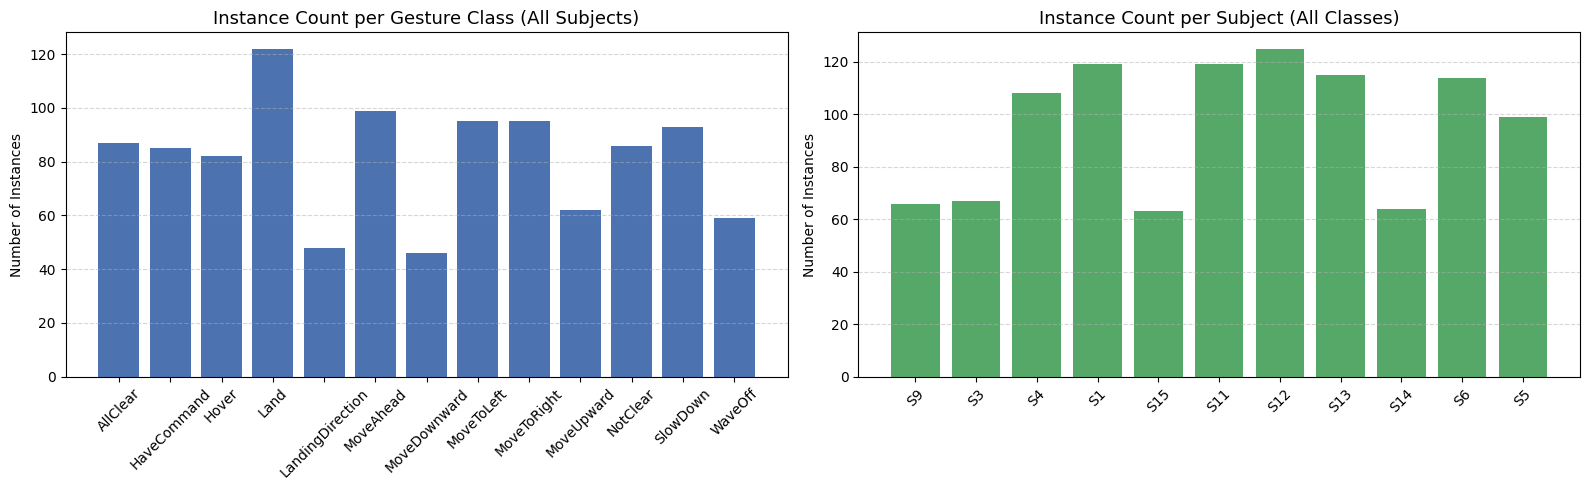

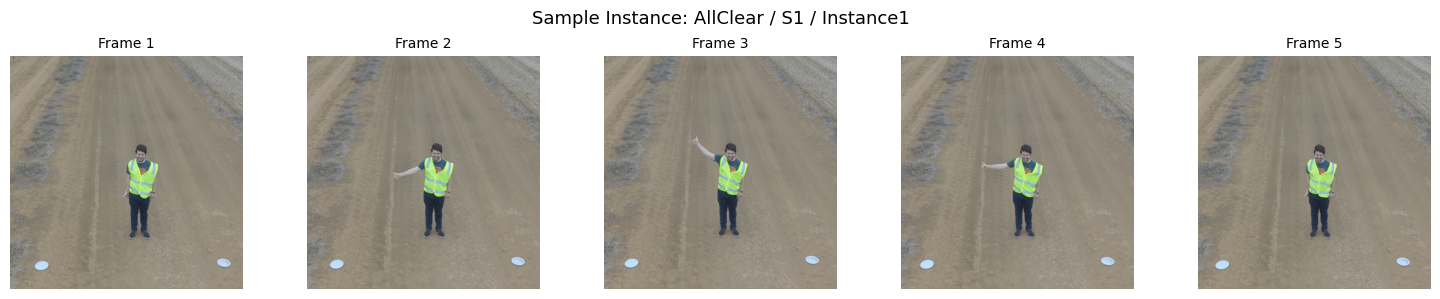

In [3]:
# Cell: Data Exploration - Class & Subject Distribution
from collections import defaultdict

root_data_path = './data_resized'
class_counts = defaultdict(int)
subject_counts = defaultdict(int)
class_subject_counts = defaultdict(lambda: defaultdict(int))
missing_frame_instances = []

classes_found = sorted([d for d in os.listdir(root_data_path) if os.path.isdir(os.path.join(root_data_path, d))])

for cls_name in classes_found:
    cls_path = os.path.join(root_data_path, cls_name)
    for subject_id in os.listdir(cls_path):
        subj_path = os.path.join(cls_path, subject_id)
        if not os.path.isdir(subj_path):
            continue
        for instance_id in os.listdir(subj_path):
            inst_path = os.path.join(subj_path, instance_id)
            if not os.path.isdir(inst_path):
                continue
            frames = glob.glob(os.path.join(inst_path, '*.png'))
            if len(frames) == 5:
                class_counts[cls_name] += 1
                subject_counts[subject_id] += 1
                class_subject_counts[cls_name][subject_id] += 1
            else:
                missing_frame_instances.append((cls_name, subject_id, instance_id, len(frames)))

print(f"Total subjects found: {len(subject_counts)}")
print(f"Total classes found: {len(class_counts)}")
print(f"Total valid (5-frame) instances: {sum(class_counts.values())}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Class balance
axes[0].bar(class_counts.keys(), class_counts.values(), color='#4C72B0')
axes[0].set_title('Instance Count per Gesture Class (All Subjects)', fontsize=13)
axes[0].set_ylabel('Number of Instances')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Subject balance
axes[1].bar(subject_counts.keys(), subject_counts.values(), color='#55A868')
axes[1].set_title('Instance Count per Subject (All Classes)', fontsize=13)
axes[1].set_ylabel('Number of Instances')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Sample Instance Visualization (Patched to ignore .DS_Store)
sample_class = classes_found[0]
sample_subject_path = os.path.join(root_data_path, sample_class)

# Filter for directories only
valid_subjects = sorted([d for d in os.listdir(sample_subject_path) if os.path.isdir(os.path.join(sample_subject_path, d))])
sample_subject = valid_subjects[0]
sample_instance_path = os.path.join(sample_subject_path, sample_subject)

# Filter for directories only
valid_instances = sorted([d for d in os.listdir(sample_instance_path) if os.path.isdir(os.path.join(sample_instance_path, d))])
sample_instance = valid_instances[0]

sample_frames = sorted(glob.glob(os.path.join(sample_instance_path, sample_instance, '*.png')))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, frame_path in enumerate(sample_frames):
    img = Image.open(frame_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(f'Frame {i+1}', fontsize=10)
    axes[i].axis('off')
fig.suptitle(f'Sample Instance: {sample_class} / {sample_subject} / {sample_instance}', fontsize=13)
plt.tight_layout()
plt.show()

## 1. Evaluation Framework & Data Split Strategy

**Objective:** To accurately evaluate how well the drone gesture classifier will perform in a real-world deployment (e.g., the upcoming client demo).

**Methodology & Justification:** A standard randomized 80/20 train-validation split would result in *data leakage*. Because the dataset consists of specific subjects (e.g., S1, S3, S11) performing multiple iterations of gestures, randomly splitting instances would mean frames of the same subject appear in both the training and validation sets. In this scenario, the network might memorize subject-specific features (e.g., clothing color, room lighting, body proportions) rather than learning the generalized spatial geometry of the hand gestures. 

To ensure the model generalizes to *unseen humans*—a mandatory requirement for demo day—we implement a **Subject-Wise Split**. We isolate a subset of subjects completely from the training phase and reserve them exclusively for validation. This rigorous evaluation framework guarantees that our validation metrics reflect actual deployment readiness.

In [4]:
class DroneGestureDataset(Dataset):
    def __init__(self, root_dir, is_train=True, val_subjects=None, transform=None):
        """
        Args:
            root_dir (str): Path to the 'data_resized' directory.
            is_train (bool): If True, loads training subjects. If False, loads validation subjects.
            val_subjects (list): List of subject folder names to be used for validation (e.g., ['S13', 'S14', 'S15']).
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.is_train = is_train
        
        if val_subjects is None:
            # Defaulting to 3 subjects for validation to test generalization
            val_subjects = ['S13', 'S14', 'S15'] 
            
        self.instances = [] 
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Traverse the hierarchical directory structure
        for cls_name in self.classes:
            cls_path = os.path.join(root_dir, cls_name)
            
            for subject_id in os.listdir(cls_path):
                subj_path = os.path.join(cls_path, subject_id)
                if not os.path.isdir(subj_path): continue

                # Subject-wise split logic
                is_val_subject = subject_id in val_subjects
                if (self.is_train and is_val_subject) or (not self.is_train and not is_val_subject):
                    continue 

                for instance_id in os.listdir(subj_path):
                    inst_path = os.path.join(subj_path, instance_id)
                    if not os.path.isdir(inst_path): continue

                    # Grab all PNG frames and sort them to maintain temporal order (1 to 5)
                    frames = sorted(glob.glob(os.path.join(inst_path, '*.png')))
                    if len(frames) == 5:
                        self.instances.append((frames, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.instances)

    def __getitem__(self, idx):
        frame_paths, label = self.instances[idx]
        frames = []

        # Load and transform each frame in the instance sequence
        for path in frame_paths:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        # Stack the 5 frames. Resulting shape: [5, Channels, Height, Width]
        frames_tensor = torch.stack(frames)
        
        return frames_tensor, label

print("Dataset class successfully defined.")

Dataset class successfully defined.


In [5]:
# Cell 4: Data Transformations & Loaders

# Define the spatial dimensions required by standard pre-trained CNNs
img_height, img_width = 224, 224

# Training transforms include data augmentation to help the model generalize
train_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    # Standard ImageNet normalization values
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Validation transforms only resize and normalize, no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Initialize the datasets using the custom class
root_data_path = './data_resized'

train_dataset = DroneGestureDataset(
    root_dir=root_data_path, 
    is_train=True, 
    transform=train_transforms
)

val_dataset = DroneGestureDataset(
    root_dir=root_data_path, 
    is_train=False, 
    transform=val_transforms
)

# Set up DataLoaders to batch and shuffle the data for training
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training instances: {len(train_dataset)}")
print(f"Validation instances: {len(val_dataset)}")

Training instances: 817
Validation instances: 242


## 2. Network Architecture: Late Fusion 2D CNN

**Objective:** To process a sequence of 5 frames per instance using only a 2-D Convolutional Neural Network, ensuring the model remains lightweight enough for an embedded drone system while still utilizing all available temporal information.

**Methodology & Justification:** Instead of modifying a 2D CNN to accept a 15-channel stacked input (Early Fusion)—which would destroy the pre-trained first-layer weights and risk overfitting on our small dataset—we implement a **Late Fusion (Feature Aggregation)** architecture. 

We utilize a pre-trained `ResNet18` as the feature extraction backbone. `ResNet18` is chosen because it offers an excellent balance between representational capacity and computational efficiency, making it highly suitable for hardware-constrained environments. 

During the forward pass, the 5 frames of an instance are passed through the 2D CNN independently. The network extracts 5 distinct feature vectors. We then apply Mean Pooling across the temporal dimension to aggregate these 5 vectors into a single robust representation of the gesture. Finally, this aggregated vector is passed to a fully connected linear layer for the 13-class prediction. This approach preserves 100% of the ImageNet pre-trained weights, efficiently utilizes all 5 frames, and strictly adheres to the hardware and architectural constraints.

In [6]:
# Cell 6: Late Fusion Network Architecture

class LateFusionGestureModel(nn.Module):
    def __init__(self, num_classes=13):
        super(LateFusionGestureModel, self).__init__()
        
        # Load a pre-trained ResNet18 backbone for feature extraction
        # Weights are downloaded automatically from torchvision
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Extract the number of input features going into the original classifier
        in_features = self.backbone.fc.in_features
        
        # Remove the final fully connected layer so the backbone only outputs feature vectors
        self.backbone.fc = nn.Identity()
        
        # Define our custom classification head for the 13 gesture classes
        self.classifier = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        # x input shape: [batch_size, num_frames, channels, height, width]
        batch_size, num_frames, c, h, w = x.size()
        
        # Merge the batch and frame dimensions so the 2D CNN can process all images
        # New shape: [batch_size * 5, 3, 224, 224]
        x = x.view(batch_size * num_frames, c, h, w)
        
        # Pass the images through the backbone to get feature vectors
        # Output shape: [batch_size * 5, 512]
        features = self.backbone(x)
        
        # Separate the batch and frame dimensions again
        # New shape: [batch_size, 5, 512]
        features = features.view(batch_size, num_frames, -1)
        
        # Aggregate the features across the 5 frames using Mean Pooling
        # This condenses the sequence into a single representative vector per instance
        # Output shape: [batch_size, 512]
        aggregated_features = torch.mean(features, dim=1)
        
        # Pass the final aggregated vector through the classification head
        # Output shape: [batch_size, 13]
        out = self.classifier(aggregated_features)
        
        return out

# Instantiate the model and move it to the configured device (CPU or GPU)
model = LateFusionGestureModel(num_classes=13).to(device)
print("Late Fusion Model successfully initialized.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/ec2-user/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 267MB/s]


Late Fusion Model successfully initialized.


In [7]:
# Cell 7: Loss Function & Optimizer

# CrossEntropyLoss automatically applies Softmax, so our model outputs raw logits
criterion = nn.CrossEntropyLoss()

# Adam optimizer is highly efficient for CNNs. 
# A learning rate of 1e-4 is a safe, stable starting point for pre-trained backbones.
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Number of complete passes through the dataset
# We keep this relatively small (e.g., 10-15) for the baseline to ensure it runs quickly on AWS
num_epochs = 10

# Dictionary to store metrics for visualization later
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("Optimizer and Loss Function configured.")

Optimizer and Loss Function configured.


In [8]:
# Cell 8: Training Loop

print("Starting Training Phase...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode (enables dropout, batch norm updates)
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        # Move data to the same device as the model (CPU or GPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 1. Zero the gradients so they don't accumulate from the previous batch
        optimizer.zero_grad()
        
        # 2. Forward pass: compute predictions
        outputs = model(inputs)
        
        # 3. Compute the loss
        loss = criterion(outputs, labels)
        
        # 4. Backward pass: compute gradients
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout, freezes batch norm)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # Disable gradient calculation to save memory and compute during validation
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Save metrics to history for visualization
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    # Print detailed output for the epoch
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")
          
print("Training Complete!")

Starting Training Phase...
Epoch [1/10] Train Loss: 1.6486, Train Acc: 46.88% | Val Loss: 1.3731, Val Acc: 47.93%
Epoch [2/10] Train Loss: 0.6632, Train Acc: 84.33% | Val Loss: 1.6611, Val Acc: 40.50%
Epoch [3/10] Train Loss: 0.3300, Train Acc: 91.92% | Val Loss: 1.3421, Val Acc: 50.83%
Epoch [4/10] Train Loss: 0.2104, Train Acc: 94.86% | Val Loss: 1.3114, Val Acc: 54.55%
Epoch [5/10] Train Loss: 0.1236, Train Acc: 97.43% | Val Loss: 1.4046, Val Acc: 55.37%
Epoch [6/10] Train Loss: 0.0786, Train Acc: 99.14% | Val Loss: 1.2706, Val Acc: 51.65%
Epoch [7/10] Train Loss: 0.0621, Train Acc: 99.14% | Val Loss: 1.3034, Val Acc: 54.55%
Epoch [8/10] Train Loss: 0.0793, Train Acc: 98.29% | Val Loss: 1.4583, Val Acc: 52.48%
Epoch [9/10] Train Loss: 0.0460, Train Acc: 99.76% | Val Loss: 1.3627, Val Acc: 55.37%
Epoch [10/10] Train Loss: 0.0660, Train Acc: 98.90% | Val Loss: 1.5236, Val Acc: 55.37%
Training Complete!


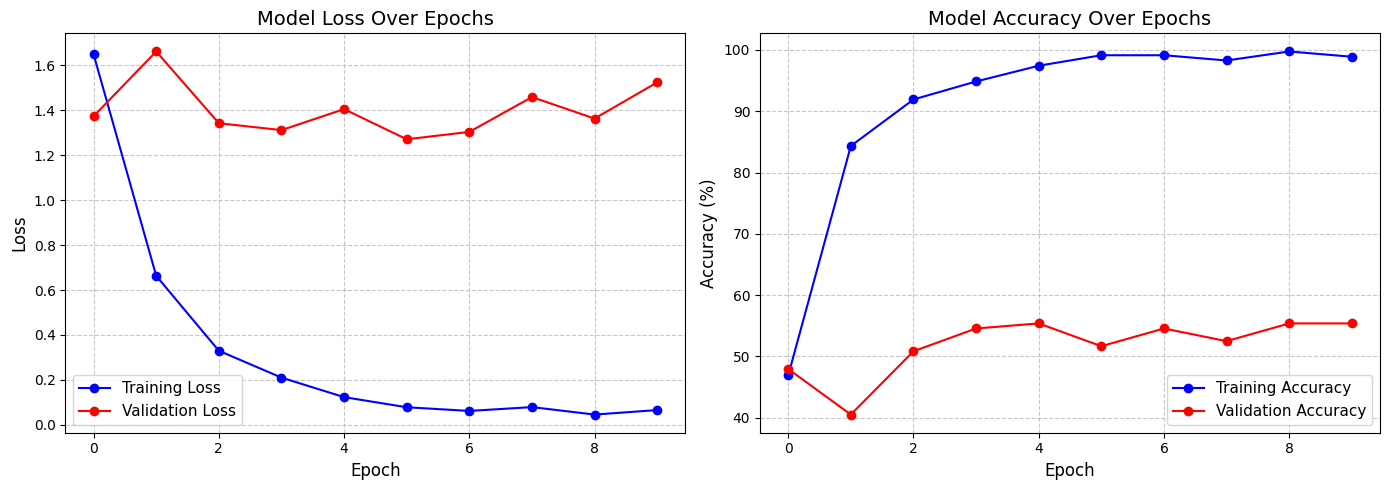

In [9]:
# Cell 9: Learning Curve Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
axes[0].plot(history['train_loss'], label='Training Loss', color='blue', marker='o')
axes[0].plot(history['val_loss'], label='Validation Loss', color='red', marker='o')
axes[0].set_title('Model Loss Over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Accuracy Curve
axes[1].plot(history['train_acc'], label='Training Accuracy', color='blue', marker='o')
axes[1].plot(history['val_acc'], label='Validation Accuracy', color='red', marker='o')
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 3. Output Analysis: Iteration 1 (Baseline)

**Observation:** The learning curves reveal severe **overfitting**. By Epoch 5, training accuracy approaches 99%, while validation accuracy stagnates around 54%. Training loss drops near zero, while validation loss remains highly volatile and elevated.

**Diagnosis:** This explicitly validates our choice of a Subject-Wise evaluation framework. The ResNet18 backbone has millions of parameters—more than enough capacity to simply memorize the physical characteristics, clothing, or lighting of the specific subjects in the training set. It effectively memorized "who" was in the image rather than the generalized geometry of the gesture itself. When forced to predict gestures on completely unseen humans in the validation set, its performance degraded significantly. 

**Next Step (Confusion Matrix):** Before modifying the architecture with regularization techniques (like Dropout or Weight Decay) to combat this overfitting, we must diagnose exactly *where* the model is confused. We will generate a Confusion Matrix to determine if the failures are uniform across all classes, or if the model is confusing specific kinematics (e.g., mistaking `MoveUpward` for `MoveDownward`).

Generating Confusion Matrix on Validation Set...


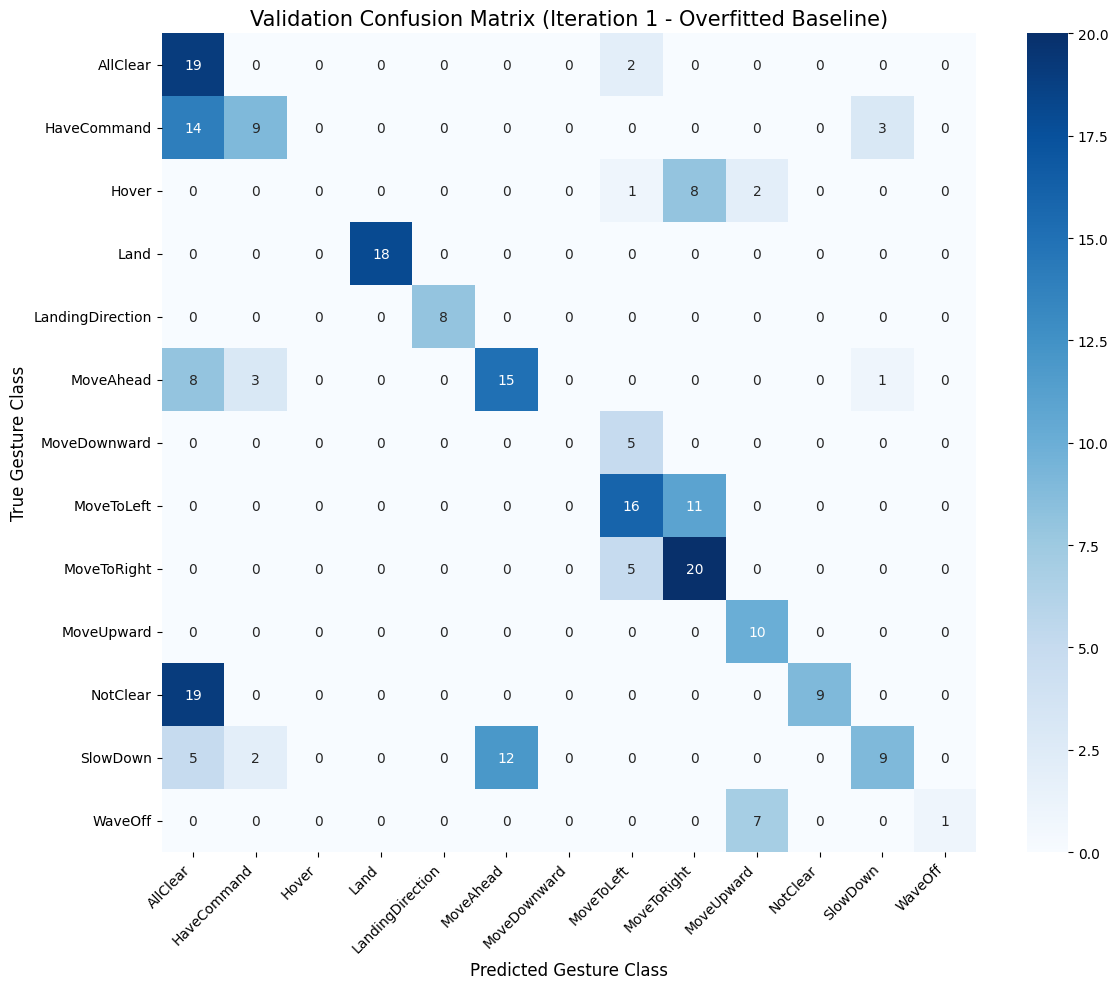

In [10]:
# Cell 11: Validation Confusion Matrix

import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Generating Confusion Matrix on Validation Set...")

# Ensure model is in evaluation mode
model.eval()

all_preds = []
all_labels = []

# Disable gradients for memory efficiency
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Get the predicted class indices
        _, preds = torch.max(outputs, 1)
        
        # Move tensors to CPU and convert to numpy arrays for sklearn
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the matrix using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=val_dataset.classes, 
            yticklabels=val_dataset.classes)

plt.title('Validation Confusion Matrix (Iteration 1 - Overfitted Baseline)', fontsize=15)
plt.ylabel('True Gesture Class', fontsize=12)
plt.xlabel('Predicted Gesture Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Iteration 2: Combating Overfitting with Regularization

**Objective:** To reduce the severe overfitting observed in the baseline model and improve validation accuracy on unseen subjects.

**Methodology & Hyper-parameter Justification:**
The baseline model memorized the training data because ResNet18 has a massive parameter space relative to our small dataset. To constrain the model's capacity and force it to learn generalized gesture kinematics, we introduce two forms of regularization:

1. **Architecture Update (Dropout):** We introduce a `nn.Dropout` layer immediately after the feature aggregation step. We select a **Dropout probability of 0.5 (50%)**, which is a standard, aggressive baseline for small datasets. This prevents co-adaptation of neurons, ensuring the classification head doesn't rely on any single dominating feature.
2. **Optimizer Update (Weight Decay/L2 Regularization):** We add a `weight_decay` hyper-parameter to the Adam optimizer. We start with a conservative value of **1e-4**. This penalizes large weight magnitudes, smoothing the decision boundaries and preventing the network from fitting to the noise/specifics of the S1-S12 training subjects.

In [11]:
# Cell 13: Regularized Model Initialization

class RegularizedLateFusionModel(nn.Module):
    def __init__(self, num_classes=13, dropout_rate=0.5):
        super(RegularizedLateFusionModel, self).__init__()
        
        # Load pre-trained backbone
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        # NEW: Dropout layer for regularization
        self.dropout = nn.Dropout(p=dropout_rate)
        
        self.classifier = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()
        x = x.view(batch_size * num_frames, c, h, w)
        
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        aggregated_features = torch.mean(features, dim=1)
        
        # NEW: Apply dropout to the aggregated features before classification
        dropped_features = self.dropout(aggregated_features)
        out = self.classifier(dropped_features)
        
        return out

# Initialize the new regularized model
reg_model = RegularizedLateFusionModel(dropout_rate=0.5).to(device)

# NEW: Add weight_decay (L2 Regularization) to the Adam optimizer
reg_optimizer = optim.Adam(reg_model.parameters(), lr=0.0001, weight_decay=1e-4)
reg_criterion = nn.CrossEntropyLoss()

print("Iteration 2: Regularized Model and Optimizer initialized.")

Iteration 2: Regularized Model and Optimizer initialized.


In [12]:
# Cell 14: Training Loop for Iteration 2

print("Starting Training Phase for Iteration 2 (Regularized)...")

reg_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    reg_model.train() 
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        reg_optimizer.zero_grad()
        outputs = reg_model(inputs)
        loss = reg_criterion(outputs, labels)
        loss.backward()
        reg_optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # --- VALIDATION PHASE ---
    reg_model.eval() 
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = reg_model(inputs)
            loss = reg_criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    reg_history['train_loss'].append(epoch_train_loss)
    reg_history['val_loss'].append(epoch_val_loss)
    reg_history['train_acc'].append(epoch_train_acc)
    reg_history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

Starting Training Phase for Iteration 2 (Regularized)...
Epoch [1/10] Train Loss: 2.0623, Train Acc: 30.84% | Val Loss: 1.6470, Val Acc: 35.95%
Epoch [2/10] Train Loss: 1.0105, Train Acc: 66.71% | Val Loss: 1.3483, Val Acc: 50.83%
Epoch [3/10] Train Loss: 0.5899, Train Acc: 82.13% | Val Loss: 1.3929, Val Acc: 45.04%
Epoch [4/10] Train Loss: 0.3636, Train Acc: 91.31% | Val Loss: 1.3266, Val Acc: 49.17%
Epoch [5/10] Train Loss: 0.2561, Train Acc: 94.25% | Val Loss: 1.5678, Val Acc: 47.93%
Epoch [6/10] Train Loss: 0.1554, Train Acc: 97.43% | Val Loss: 1.4323, Val Acc: 47.52%
Epoch [7/10] Train Loss: 0.1168, Train Acc: 98.04% | Val Loss: 1.4235, Val Acc: 45.45%
Epoch [8/10] Train Loss: 0.1245, Train Acc: 96.33% | Val Loss: 2.5869, Val Acc: 38.84%
Epoch [9/10] Train Loss: 0.1016, Train Acc: 98.16% | Val Loss: 1.3587, Val Acc: 51.24%
Epoch [10/10] Train Loss: 0.0550, Train Acc: 99.39% | Val Loss: 1.5873, Val Acc: 50.00%


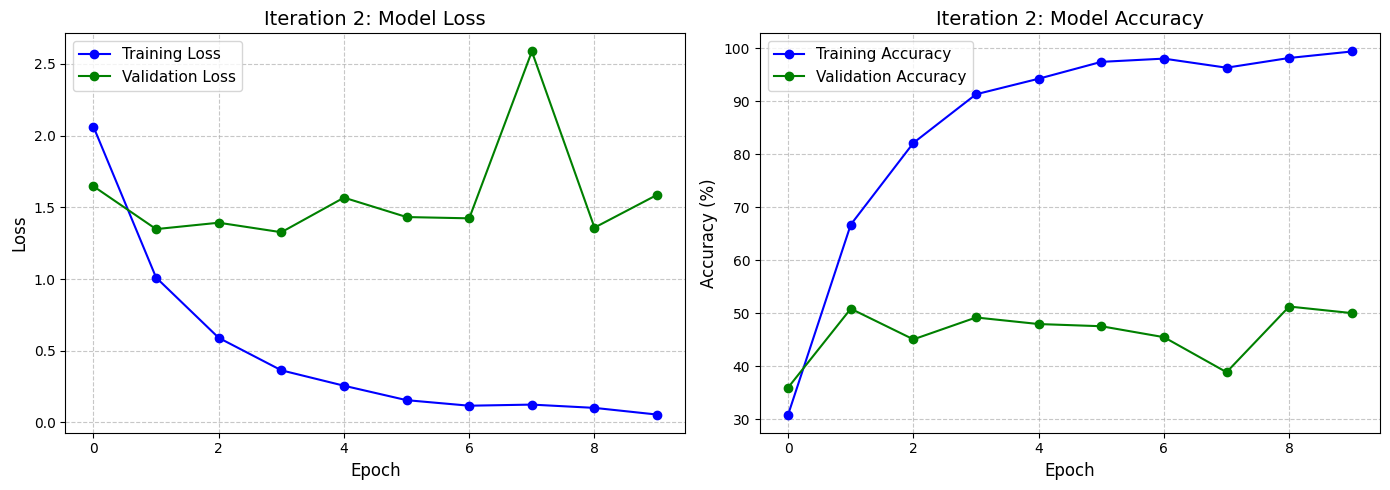

In [13]:
# Cell 15: Iteration 2 Learning Curve Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve (Iter 2)
axes[0].plot(reg_history['train_loss'], label='Training Loss', color='blue', marker='o')
axes[0].plot(reg_history['val_loss'], label='Validation Loss', color='green', marker='o') # Using green to distinguish from baseline
axes[0].set_title('Iteration 2: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Accuracy Curve (Iter 2)
axes[1].plot(reg_history['train_acc'], label='Training Accuracy', color='blue', marker='o')
axes[1].plot(reg_history['val_acc'], label='Validation Accuracy', color='green', marker='o')
axes[1].set_title('Iteration 2: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
# Cell: Iteration 3 - Aggressive Augmentation Pipeline

train_transforms_v3 = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

val_transforms_v3 = val_transforms

train_dataset_v3 = DroneGestureDataset(
    root_dir=root_data_path,
    is_train=True,
    transform=train_transforms_v3
)

val_dataset_v3 = DroneGestureDataset(
    root_dir=root_data_path,
    is_train=False,
    transform=val_transforms_v3
)

train_loader_v3 = DataLoader(train_dataset_v3, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_v3 = DataLoader(val_dataset_v3, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Iteration 3 Training instances: {len(train_dataset_v3)}")
print(f"Iteration 3 Validation instances: {len(val_dataset_v3)}")

Iteration 3 Training instances: 817
Iteration 3 Validation instances: 242


In [15]:
# Cell: Iteration 3 - Frozen Backbone Model

class FrozenBackboneGestureModel(nn.Module):
    def __init__(self, num_classes=13, dropout_rate=0.5):
        super(FrozenBackboneGestureModel, self).__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features, num_classes)

    def train(self, mode=True):
        # Keep the frozen backbone's BatchNorm layers in eval() permanently,
        # even when the rest of the model switches to train mode.
        super().train(mode)
        self.backbone.eval()
        return self

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()
        x = x.view(batch_size * num_frames, c, h, w)

        with torch.no_grad():
            features = self.backbone(x)

        features = features.view(batch_size, num_frames, -1)
        aggregated_features = torch.mean(features, dim=1)

        dropped_features = self.dropout(aggregated_features)
        out = self.classifier(dropped_features)

        return out

frozen_model = FrozenBackboneGestureModel(dropout_rate=0.5).to(device)
frozen_model.train()

trainable_params = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in frozen_model.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,} total")

frozen_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, frozen_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
frozen_criterion = nn.CrossEntropyLoss()

print("Iteration 3: Frozen-backbone model and optimizer initialized.")

Trainable parameters: 6,669 / 11,183,181 total
Iteration 3: Frozen-backbone model and optimizer initialized.


In [16]:
# Cell: Iteration 3 - Training Loop (Frozen Backbone + Aggressive Augmentation)

print("Starting Training Phase for Iteration 3 (Frozen Backbone + Augmentation)...")

frozen_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

num_epochs_v3 = 15

for epoch in range(num_epochs_v3):
    frozen_model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_v3:
        inputs, labels = inputs.to(device), labels.to(device)

        frozen_optimizer.zero_grad()
        outputs = frozen_model(inputs)
        loss = frozen_criterion(outputs, labels)
        loss.backward()
        frozen_optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader_v3.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    frozen_model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader_v3:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = frozen_model(inputs)
            loss = frozen_criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader_v3.dataset)
    epoch_val_acc = (correct_val / total_val) * 100

    frozen_history['train_loss'].append(epoch_train_loss)
    frozen_history['val_loss'].append(epoch_val_loss)
    frozen_history['train_acc'].append(epoch_train_acc)
    frozen_history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs_v3}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

print("Training Complete!")

Starting Training Phase for Iteration 3 (Frozen Backbone + Augmentation)...
Epoch [1/15] Train Loss: 2.6974, Train Acc: 12.61% | Val Loss: 2.3302, Val Acc: 14.46%
Epoch [2/15] Train Loss: 2.5175, Train Acc: 15.91% | Val Loss: 2.1829, Val Acc: 21.07%
Epoch [3/15] Train Loss: 2.3644, Train Acc: 20.32% | Val Loss: 2.1100, Val Acc: 28.10%
Epoch [4/15] Train Loss: 2.2915, Train Acc: 22.40% | Val Loss: 2.0565, Val Acc: 25.62%
Epoch [5/15] Train Loss: 2.1809, Train Acc: 26.68% | Val Loss: 2.0882, Val Acc: 25.62%
Epoch [6/15] Train Loss: 2.1340, Train Acc: 27.78% | Val Loss: 1.9638, Val Acc: 24.38%
Epoch [7/15] Train Loss: 2.0521, Train Acc: 30.23% | Val Loss: 1.9740, Val Acc: 25.21%
Epoch [8/15] Train Loss: 2.0709, Train Acc: 26.93% | Val Loss: 2.0051, Val Acc: 30.58%
Epoch [9/15] Train Loss: 2.0042, Train Acc: 32.31% | Val Loss: 1.9515, Val Acc: 27.69%
Epoch [10/15] Train Loss: 1.9297, Train Acc: 32.80% | Val Loss: 1.9825, Val Acc: 30.17%
Epoch [11/15] Train Loss: 1.9564, Train Acc: 33.05% |

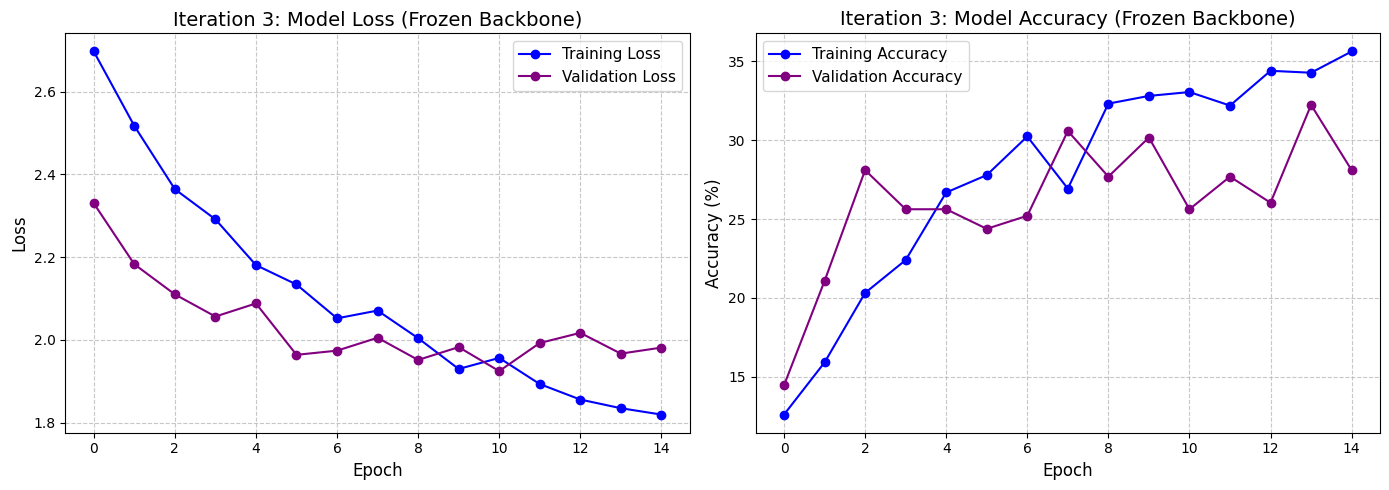

In [17]:
# Cell: Iteration 3 Learning Curve Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(frozen_history['train_loss'], label='Training Loss', color='blue', marker='o')
axes[0].plot(frozen_history['val_loss'], label='Validation Loss', color='purple', marker='o')
axes[0].set_title('Iteration 3: Model Loss (Frozen Backbone)', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(frozen_history['train_acc'], label='Training Accuracy', color='blue', marker='o')
axes[1].plot(frozen_history['val_acc'], label='Validation Accuracy', color='purple', marker='o')
axes[1].set_title('Iteration 3: Model Accuracy (Frozen Backbone)', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [18]:
# Cell: Reusable Training/Evaluation Loop
# Refactored so every iteration (2, 3, 3b, ...) calls the same tested code —
# removes copy-paste risk and lets us directly compare iterations afterward.

def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs, label=""):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = (correct_train / total_train) * 100

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = (correct_val / total_val) * 100

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        print(f"[{label}] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

    return history

print("Reusable train_model() defined.")

Reusable train_model() defined.


In [19]:
# Cell: Iteration 3b - Isolation Experiment
# Same frozen backbone as Iteration 3, but trained on the ORIGINAL mild-augmentation
# loaders (train_loader / val_loader from Iteration 1/2) instead of train_loader_v3.
# Purpose: isolate whether Iteration 3's underfitting came from freezing the backbone
# or from the aggressive augmentation, by changing only one variable at a time.

frozen_model_3b = FrozenBackboneGestureModel(dropout_rate=0.5).to(device)
frozen_model_3b.train()

trainable_params_3b = sum(p.numel() for p in frozen_model_3b.parameters() if p.requires_grad)
total_params_3b = sum(p.numel() for p in frozen_model_3b.parameters())
print(f"Trainable parameters: {trainable_params_3b:,} / {total_params_3b:,} total")

frozen_optimizer_3b = optim.Adam(
    filter(lambda p: p.requires_grad, frozen_model_3b.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
frozen_criterion_3b = nn.CrossEntropyLoss()

print("Starting Training Phase for Iteration 3b (Frozen Backbone + MILD Augmentation)...")
history_3b = train_model(
    frozen_model_3b, frozen_optimizer_3b, frozen_criterion_3b,
    train_loader, val_loader,   # <-- original mild-augmentation loaders, on purpose
    num_epochs=15, label="Iter 3b"
)
print("Training Complete!")

Trainable parameters: 6,669 / 11,183,181 total
Starting Training Phase for Iteration 3b (Frozen Backbone + MILD Augmentation)...
[Iter 3b] Epoch [1/15] Train Loss: 2.6878, Train Acc: 14.69% | Val Loss: 2.3042, Val Acc: 21.90%
[Iter 3b] Epoch [2/15] Train Loss: 2.4114, Train Acc: 20.93% | Val Loss: 2.1300, Val Acc: 18.18%
[Iter 3b] Epoch [3/15] Train Loss: 2.2512, Train Acc: 22.89% | Val Loss: 2.0454, Val Acc: 19.42%
[Iter 3b] Epoch [4/15] Train Loss: 2.1247, Train Acc: 27.91% | Val Loss: 2.0687, Val Acc: 19.01%
[Iter 3b] Epoch [5/15] Train Loss: 2.0465, Train Acc: 32.56% | Val Loss: 2.0312, Val Acc: 22.31%
[Iter 3b] Epoch [6/15] Train Loss: 1.9400, Train Acc: 35.50% | Val Loss: 1.9777, Val Acc: 25.21%
[Iter 3b] Epoch [7/15] Train Loss: 1.9162, Train Acc: 33.05% | Val Loss: 1.9973, Val Acc: 26.45%
[Iter 3b] Epoch [8/15] Train Loss: 1.8376, Train Acc: 35.99% | Val Loss: 1.9862, Val Acc: 26.45%
[Iter 3b] Epoch [9/15] Train Loss: 1.7707, Train Acc: 37.82% | Val Loss: 2.0720, Val Acc: 22.31

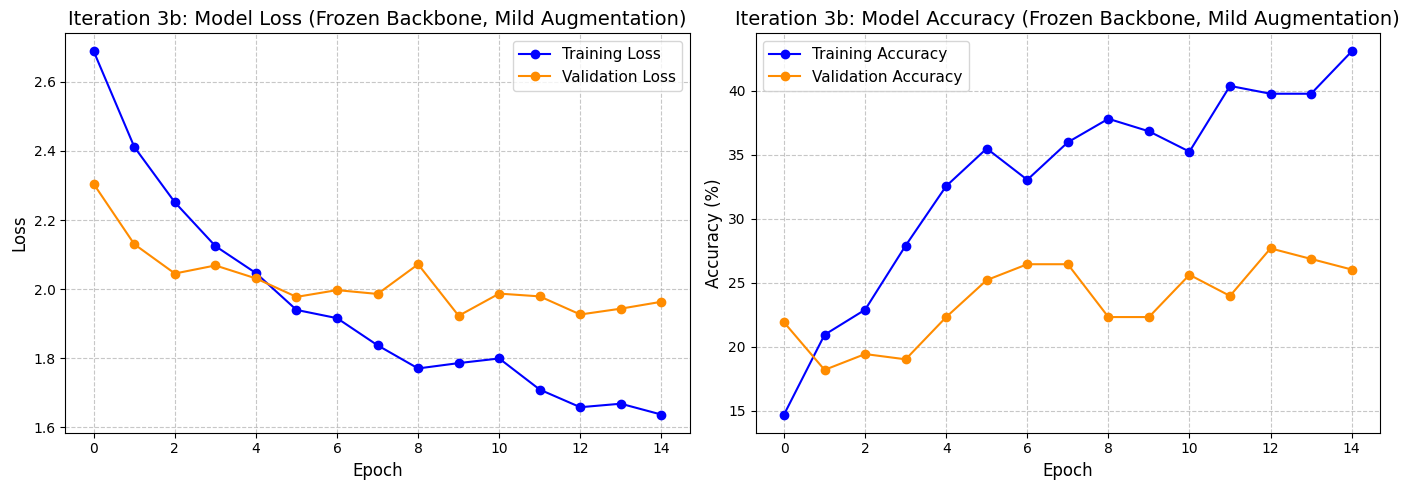

In [20]:
# Cell: Iteration 3b Learning Curve Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_3b['train_loss'], label='Training Loss', color='blue', marker='o')
axes[0].plot(history_3b['val_loss'], label='Validation Loss', color='darkorange', marker='o')
axes[0].set_title('Iteration 3b: Model Loss (Frozen Backbone, Mild Augmentation)', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(history_3b['train_acc'], label='Training Accuracy', color='blue', marker='o')
axes[1].plot(history_3b['val_acc'], label='Validation Accuracy', color='darkorange', marker='o')
axes[1].set_title('Iteration 3b: Model Accuracy (Frozen Backbone, Mild Augmentation)', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

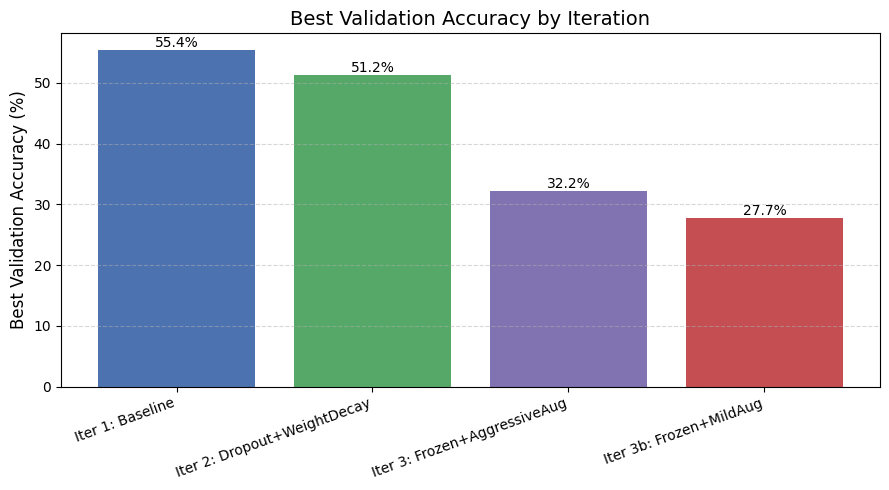

Iter 1: Baseline: 55.37%
Iter 2: Dropout+WeightDecay: 51.24%
Iter 3: Frozen+AggressiveAug: 32.23%
Iter 3b: Frozen+MildAug: 27.69%


In [21]:
# Cell: Cross-Iteration Comparison — best validation accuracy per iteration
# Pulls final/best val_acc from each history dict you've already run.
# If a variable name below doesn't exist yet (e.g. you skipped an iteration),
# comment out its line.

comparison = {
    "Iter 1: Baseline":                    max(history['val_acc']),
    "Iter 2: Dropout+WeightDecay":          max(reg_history['val_acc']),
    "Iter 3: Frozen+AggressiveAug":         max(frozen_history['val_acc']),
    "Iter 3b: Frozen+MildAug":              max(history_3b['val_acc']),
}

plt.figure(figsize=(9, 5))
bars = plt.bar(comparison.keys(), comparison.values(), color=['#4C72B0', '#55A868', '#8172B2', '#C44E52'])
plt.ylabel("Best Validation Accuracy (%)", fontsize=12)
plt.title("Best Validation Accuracy by Iteration", fontsize=14)
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

for k, v in comparison.items():
    print(f"{k}: {v:.2f}%")

In [22]:
# Cell: Iteration 4 - Partial Unfreeze (layer4 only)
# Diagnosis from Iter 3/3b: fully freezing the backbone closes the train/val gap
# (identity memorization is gone) but underfits — a linear head on fixed ImageNet
# features doesn't have enough representational range for this task. Here we give
# the network back a small amount of adaptable capacity: only the final residual
# block (layer4) is unfrozen, with a much smaller LR than the head, so it can
# adapt features toward gesture geometry without regaining the freedom to
# re-memorize subject identity end-to-end.

class PartialUnfreezeGestureModel(nn.Module):
    def __init__(self, num_classes=13, dropout_rate=0.5, unfreeze_layer='layer4'):
        super(PartialUnfreezeGestureModel, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Freeze everything first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Then unfreeze just the named block
        for param in getattr(self.backbone, unfreeze_layer).parameters():
            param.requires_grad = True

        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features, num_classes)
        self.unfreeze_layer = unfreeze_layer

    def train(self, mode=True):
        # Keep every still-frozen backbone submodule (and its BatchNorm) pinned
        # to eval mode; only the unfrozen block + head track training-mode stats.
        super().train(mode)
        for name, module in self.backbone.named_children():
            if name != self.unfreeze_layer:
                module.eval()
        return self

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()
        x = x.view(batch_size * num_frames, c, h, w)
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        aggregated_features = torch.mean(features, dim=1)
        dropped_features = self.dropout(aggregated_features)
        out = self.classifier(dropped_features)
        return out

partial_model = PartialUnfreezeGestureModel(dropout_rate=0.5, unfreeze_layer='layer4').to(device)
partial_model.train()

trainable_params_4 = sum(p.numel() for p in partial_model.parameters() if p.requires_grad)
total_params_4 = sum(p.numel() for p in partial_model.parameters())
print(f"Trainable parameters: {trainable_params_4:,} / {total_params_4:,} total")

# Differential learning rates: layer4 gets a tiny LR since it's a pre-trained
# block we only want to nudge, the head gets a normal LR since it's trained
# from scratch.
partial_optimizer = optim.Adam([
    {'params': partial_model.backbone.layer4.parameters(), 'lr': 1e-5},
    {'params': partial_model.classifier.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)
partial_criterion = nn.CrossEntropyLoss()

print("Iteration 4: Partial-unfreeze model and optimizer initialized.")

Trainable parameters: 8,400,397 / 11,183,181 total
Iteration 4: Partial-unfreeze model and optimizer initialized.


In [23]:
# Cell: Iteration 4 - Training Loop (Partial Unfreeze, layer4)

print("Starting Training Phase for Iteration 4 (Partial Unfreeze: layer4)...")
history_4 = train_model(
    partial_model, partial_optimizer, partial_criterion,
    train_loader_v3, val_loader_v3,   # aggressive augmentation, per Iter 3 vs 3b result
    num_epochs=15, label="Iter 4"
)
print("Training Complete!")

Starting Training Phase for Iteration 4 (Partial Unfreeze: layer4)...
[Iter 4] Epoch [1/15] Train Loss: 2.5789, Train Acc: 16.40% | Val Loss: 2.2524, Val Acc: 23.14%
[Iter 4] Epoch [2/15] Train Loss: 2.1921, Train Acc: 28.15% | Val Loss: 2.0192, Val Acc: 22.31%
[Iter 4] Epoch [3/15] Train Loss: 1.9416, Train Acc: 32.07% | Val Loss: 1.7756, Val Acc: 37.60%
[Iter 4] Epoch [4/15] Train Loss: 1.7053, Train Acc: 41.00% | Val Loss: 1.7352, Val Acc: 25.21%
[Iter 4] Epoch [5/15] Train Loss: 1.4861, Train Acc: 46.14% | Val Loss: 1.7181, Val Acc: 32.64%
[Iter 4] Epoch [6/15] Train Loss: 1.4010, Train Acc: 48.59% | Val Loss: 1.7563, Val Acc: 27.27%
[Iter 4] Epoch [7/15] Train Loss: 1.2711, Train Acc: 53.61% | Val Loss: 1.5827, Val Acc: 33.88%
[Iter 4] Epoch [8/15] Train Loss: 1.1898, Train Acc: 56.06% | Val Loss: 1.5824, Val Acc: 35.12%
[Iter 4] Epoch [9/15] Train Loss: 1.0638, Train Acc: 57.53% | Val Loss: 1.5168, Val Acc: 37.60%
[Iter 4] Epoch [10/15] Train Loss: 1.0199, Train Acc: 59.49% | Val

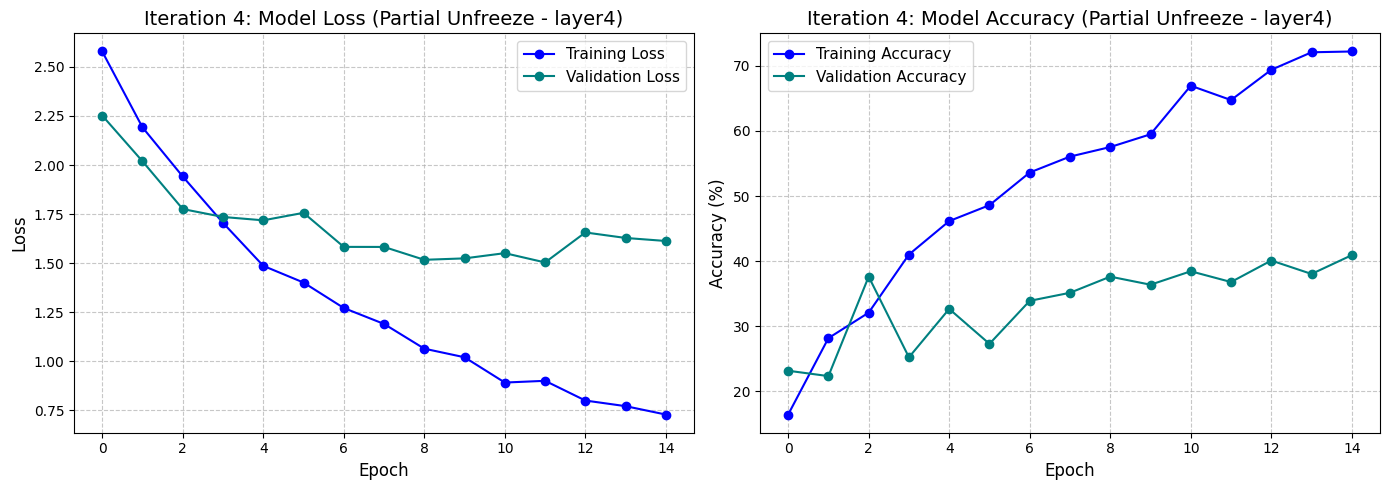

In [24]:
# Cell: Iteration 4 Learning Curve Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_4['train_loss'], label='Training Loss', color='blue', marker='o')
axes[0].plot(history_4['val_loss'], label='Validation Loss', color='teal', marker='o')
axes[0].set_title('Iteration 4: Model Loss (Partial Unfreeze - layer4)', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(history_4['train_acc'], label='Training Accuracy', color='blue', marker='o')
axes[1].plot(history_4['val_acc'], label='Validation Accuracy', color='teal', marker='o')
axes[1].set_title('Iteration 4: Model Accuracy (Partial Unfreeze - layer4)', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

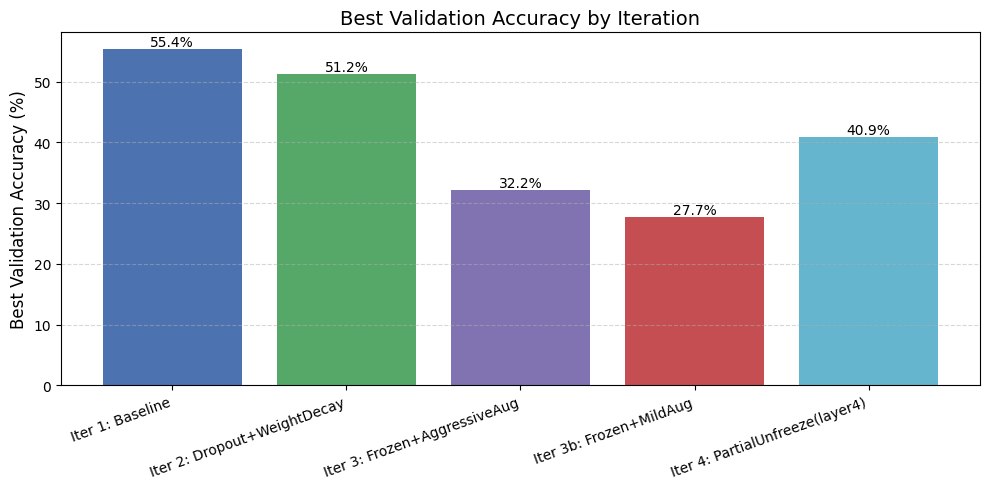

Iter 1: Baseline: 55.37%
Iter 2: Dropout+WeightDecay: 51.24%
Iter 3: Frozen+AggressiveAug: 32.23%
Iter 3b: Frozen+MildAug: 27.69%
Iter 4: PartialUnfreeze(layer4): 40.91%


In [25]:
comparison["Iter 4: PartialUnfreeze(layer4)"] = max(history_4['val_acc'])

plt.figure(figsize=(10, 5))
bars = plt.bar(comparison.keys(), comparison.values(),
                color=['#4C72B0', '#55A868', '#8172B2', '#C44E52', '#64B5CD'])
plt.ylabel("Best Validation Accuracy (%)", fontsize=12)
plt.title("Best Validation Accuracy by Iteration", fontsize=14)
plt.xticks(rotation=20, ha='right')
for bar, val in zip(bars, comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}%", ha='center', fontsize=10)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

for k, v in comparison.items():
    print(f"{k}: {v:.2f}%")

In [26]:
# Cell: Reusable Training and Evaluation Loop (with Checkpointing)
# Centralizing the training logic ensures consistency across experiments.
# This updated version includes a mechanism to save the model's weights 
# at its peak validation accuracy, rather than just keeping the final epoch's state.

def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs, label="", save_best_path=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = (correct_train / total_train) * 100

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = (correct_val / total_val) * 100

        # Store metrics
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        # Checkpoint saving logic
        improved = ""
        if save_best_path is not None and epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), save_best_path)
            improved = "  <-- New best model, checkpoint saved!"

        print(f"[{label}] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%{improved}")

    return history

print("train_model() updated with checkpoint support.")

train_model() updated with checkpoint support.


In [27]:
# Cell: Iteration 5 - Full Fine-Tune with Advanced Regularization
# Rationale: Previous iterations proved that restricting the backbone capacity 
# (freezing layers) caused severe underfitting. To resolve this, we restore full 
# trainable capacity to the ResNet18 backbone, but apply aggressive regularization 
# to combat identity memorization. This includes higher Dropout (0.6), stricter 
# L2 Weight Decay (5e-4), and Label Smoothing to penalize overconfident predictions.

class Iteration5Model(nn.Module):
    def __init__(self, num_classes=13, dropout_rate=0.6):
        super(Iteration5Model, self).__init__()
        
        # Keep the entire backbone trainable (no freezing)
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        # Increased dropout rate for stricter spatial regularization
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()
        x = x.view(batch_size * num_frames, c, h, w)
        
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        aggregated_features = torch.mean(features, dim=1)
        
        dropped_features = self.dropout(aggregated_features)
        out = self.classifier(dropped_features)
        
        return out

# Initialize the model and move to device
model_5 = Iteration5Model(dropout_rate=0.6).to(device)

# Apply stronger weight decay (5e-4) compared to previous iterations
optimizer_5 = optim.Adam(model_5.parameters(), lr=1e-4, weight_decay=5e-4)

# Apply Label Smoothing (0.1) to prevent the network from fitting to noise
criterion_5 = nn.CrossEntropyLoss(label_smoothing=0.1)

print("Iteration 5: Full fine-tune model with stronger regularization initialized.")

Iteration 5: Full fine-tune model with stronger regularization initialized.


In [28]:
# Cell: Iteration 5 - Training Execution
# We pair the heavily regularized network with the aggressive augmentation 
# pipeline (train_loader_v3) to maximize generalization.

print("Starting Training Phase for Iteration 5...")
history_5 = train_model(
    model_5, optimizer_5, criterion_5,
    train_loader_v3, val_loader_v3, 
    num_epochs=15, 
    label="Iter 5",
    save_best_path="./best_iter5_model.pt"  # Saves safely inside your AWS workspace
)
print("Training Complete!")
print(f"Best validation accuracy achieved: {max(history_5['val_acc']):.2f}%")

Starting Training Phase for Iteration 5...
[Iter 5] Epoch [1/15] Train Loss: 2.3721, Train Acc: 23.13% | Val Loss: 1.7790, Val Acc: 37.60%  <-- New best model, checkpoint saved!
[Iter 5] Epoch [2/15] Train Loss: 1.6497, Train Acc: 50.31% | Val Loss: 1.5272, Val Acc: 50.00%  <-- New best model, checkpoint saved!
[Iter 5] Epoch [3/15] Train Loss: 1.3293, Train Acc: 64.38% | Val Loss: 1.5081, Val Acc: 51.65%  <-- New best model, checkpoint saved!
[Iter 5] Epoch [4/15] Train Loss: 1.0940, Train Acc: 76.74% | Val Loss: 1.5562, Val Acc: 48.35%
[Iter 5] Epoch [5/15] Train Loss: 0.9697, Train Acc: 85.56% | Val Loss: 1.7317, Val Acc: 58.26%  <-- New best model, checkpoint saved!
[Iter 5] Epoch [6/15] Train Loss: 0.8843, Train Acc: 88.98% | Val Loss: 1.6169, Val Acc: 53.31%
[Iter 5] Epoch [7/15] Train Loss: 0.8026, Train Acc: 93.15% | Val Loss: 1.8895, Val Acc: 57.85%
[Iter 5] Epoch [8/15] Train Loss: 0.7588, Train Acc: 95.47% | Val Loss: 1.6948, Val Acc: 52.48%
[Iter 5] Epoch [9/15] Train Loss:

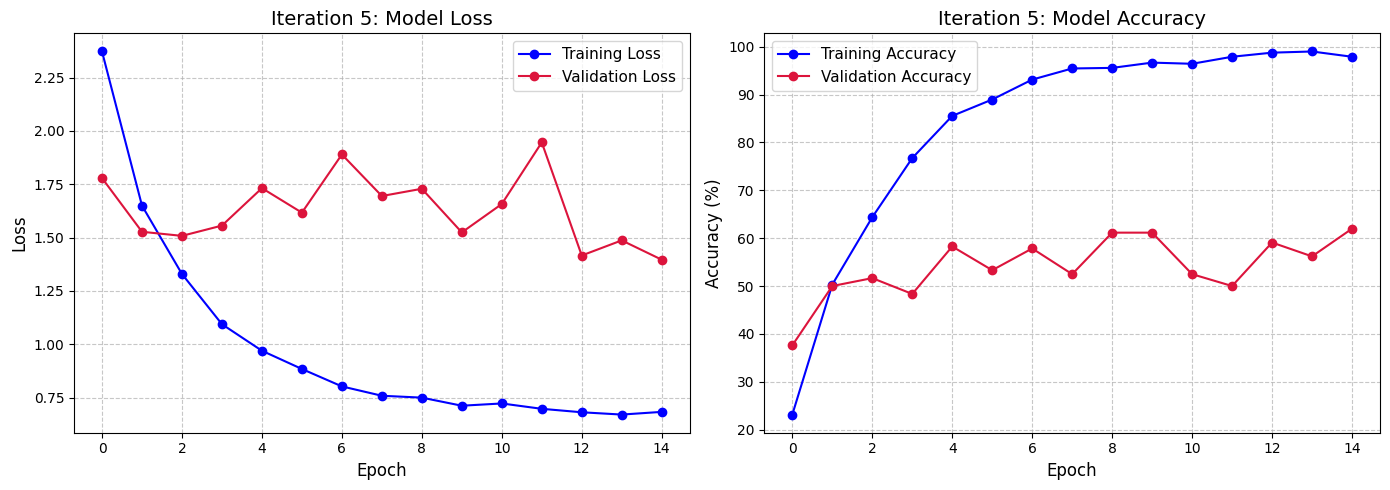

In [29]:
# Cell: Iteration 5 Learning Curve Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(history_5['train_loss'], label='Training Loss', color='blue', marker='o')
axes[0].plot(history_5['val_loss'], label='Validation Loss', color='crimson', marker='o')
axes[0].set_title('Iteration 5: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Accuracy Curve
axes[1].plot(history_5['train_acc'], label='Training Accuracy', color='blue', marker='o')
axes[1].plot(history_5['val_acc'], label='Validation Accuracy', color='crimson', marker='o')
axes[1].set_title('Iteration 5: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

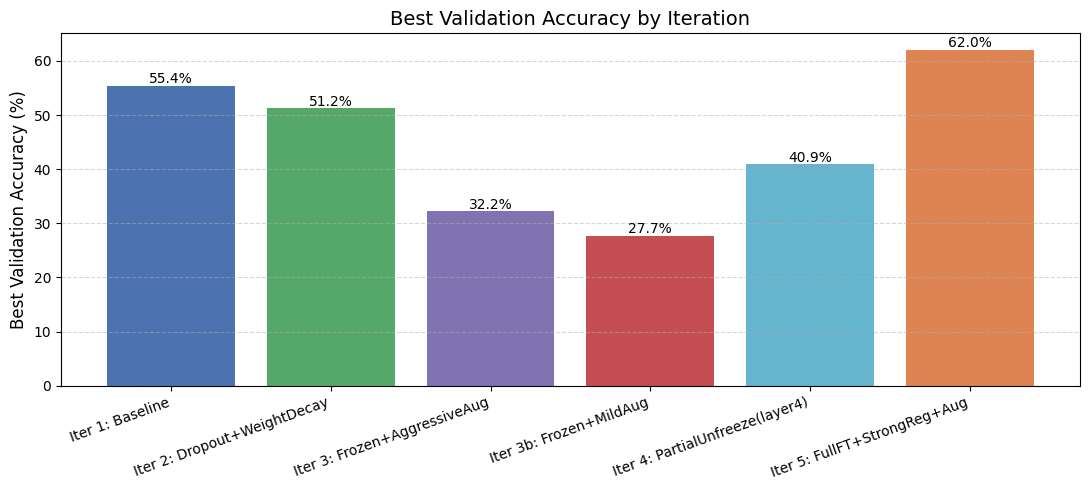

Iter 1: Baseline: 55.37%
Iter 2: Dropout+WeightDecay: 51.24%
Iter 3: Frozen+AggressiveAug: 32.23%
Iter 3b: Frozen+MildAug: 27.69%
Iter 4: PartialUnfreeze(layer4): 40.91%
Iter 5: FullFT+StrongReg+Aug: 61.98%


In [30]:
# Cell: Cross-Iteration Performance Comparison
# Visualizing the progression of validation accuracy across all structural iterations.

comparison["Iter 5: FullFT+StrongReg+Aug"] = max(history_5['val_acc'])

plt.figure(figsize=(11, 5))
bars = plt.bar(comparison.keys(), comparison.values(),
                color=['#4C72B0', '#55A868', '#8172B2', '#C44E52', '#64B5CD', '#DD8452'])
plt.ylabel("Best Validation Accuracy (%)", fontsize=12)
plt.title("Best Validation Accuracy by Iteration", fontsize=14)
plt.xticks(rotation=20, ha='right')

for bar, val in zip(bars, comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}%", ha='center', fontsize=10)
    
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

for k, v in comparison.items():
    print(f"{k}: {v:.2f}%")

In [31]:
# Cell: Load Iteration 5's Best Checkpoint
# Reload the saved checkpoint before generating any final metrics.

model_5.load_state_dict(torch.load("./best_iter5_model.pt", map_location=device, weights_only=True))
model_5.eval()

# UPDATED: Dynamically print the actual max validation accuracy instead of hardcoding it
print(f"Loaded best Iteration 5 checkpoint (val acc {max(history_5['val_acc']):.2f}%).")

Loaded best Iteration 5 checkpoint (val acc 61.98%).


In [32]:
# Cell: Update train_model to support Learning Rate Scheduling

def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs, label="", save_best_path=None, scheduler=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = (correct_train / total_train) * 100

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = (correct_val / total_val) * 100
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        improved = ""
        if save_best_path is not None and epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), save_best_path)
            improved = "  <-- New best, checkpoint saved"

        # NEW: Step the scheduler based on validation accuracy
        if scheduler is not None:
            scheduler.step(epoch_val_acc)

        print(f"[{label}] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%{improved}")

    return history

In [33]:
# Cell: Iteration 6 - The Final Polish (Scheduler + More Epochs)
# We deploy a ReduceLROnPlateau scheduler with patience=4 to account for the noisy 
# validation curve. We removed 'verbose=True' to ensure compatibility with recent 
# PyTorch versions.

model_6 = Iteration5Model(dropout_rate=0.6).to(device)
optimizer_6 = optim.Adam(model_6.parameters(), lr=1e-4, weight_decay=5e-4)
criterion_6 = nn.CrossEntropyLoss(label_smoothing=0.1)

# UPDATED: patience=4, removed verbose
scheduler_6 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_6, mode='max', factor=0.5, patience=4
)

print("Starting Training Phase for Iteration 6 (Final Polish)...")
history_6 = train_model(
    model_6, optimizer_6, criterion_6,
    train_loader_v3, val_loader_v3, 
    num_epochs=25, 
    label="Iter 6",
    save_best_path="./best_final_model.pt",
    scheduler=scheduler_6
)
print("Training Complete!")
print(f"Best validation accuracy achieved: {max(history_6['val_acc']):.2f}%")

Starting Training Phase for Iteration 6 (Final Polish)...
[Iter 6] Epoch [1/25] Train Loss: 2.3511, Train Acc: 26.19% | Val Loss: 1.7897, Val Acc: 36.78%  <-- New best, checkpoint saved
[Iter 6] Epoch [2/25] Train Loss: 1.6026, Train Acc: 51.90% | Val Loss: 1.5266, Val Acc: 46.69%  <-- New best, checkpoint saved
[Iter 6] Epoch [3/25] Train Loss: 1.2321, Train Acc: 70.01% | Val Loss: 1.4266, Val Acc: 49.59%  <-- New best, checkpoint saved
[Iter 6] Epoch [4/25] Train Loss: 1.0584, Train Acc: 79.80% | Val Loss: 1.6449, Val Acc: 54.55%  <-- New best, checkpoint saved
[Iter 6] Epoch [5/25] Train Loss: 0.9424, Train Acc: 85.31% | Val Loss: 1.5261, Val Acc: 55.79%  <-- New best, checkpoint saved
[Iter 6] Epoch [6/25] Train Loss: 0.8531, Train Acc: 91.19% | Val Loss: 1.5570, Val Acc: 59.09%  <-- New best, checkpoint saved
[Iter 6] Epoch [7/25] Train Loss: 0.7850, Train Acc: 94.12% | Val Loss: 1.8502, Val Acc: 49.17%
[Iter 6] Epoch [8/25] Train Loss: 0.7729, Train Acc: 94.61% | Val Loss: 2.2004

In [34]:
# Cell: Load Iteration 6's Best Checkpoint
# Reload the highest performing weights into memory before evaluation.

model_6.load_state_dict(torch.load("./best_final_model.pt", map_location=device, weights_only=True))
model_6.eval()
print(f"Loaded best Iteration 6 checkpoint (val acc {max(history_6['val_acc']):.2f}%).")

Loaded best Iteration 6 checkpoint (val acc 68.60%).


In [35]:
# Cell: Final Train / Validation / Test Subject Split & Loaders
# Rationale: We re-partition strictly into three disjoint subject groups to prevent data leakage.
# The Test set is touched exactly once to report deployment-realistic performance.

TRAIN_SUBJECTS = ['S1', 'S3', 'S4', 'S5', 'S6', 'S9']   
VAL_SUBJECTS   = ['S11', 'S12']                          
TEST_SUBJECTS  = ['S13', 'S14', 'S15']                   

class GestureDatasetBySubjects(Dataset):
    def __init__(self, root_dir, subjects, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.subjects = set(subjects)
        self.instances = []
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        for cls_name in self.classes:
            cls_path = os.path.join(root_dir, cls_name)
            for subject_id in os.listdir(cls_path):
                if subject_id not in self.subjects: continue
                subj_path = os.path.join(cls_path, subject_id)
                if not os.path.isdir(subj_path): continue
                for instance_id in os.listdir(subj_path):
                    inst_path = os.path.join(subj_path, instance_id)
                    if not os.path.isdir(inst_path): continue
                    frames = sorted(glob.glob(os.path.join(inst_path, '*.png')))
                    if len(frames) == 5:
                        self.instances.append((frames, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.instances)

    def __getitem__(self, idx):
        frame_paths, label = self.instances[idx]
        frames = [self.transform(Image.open(path).convert('RGB')) if self.transform else Image.open(path).convert('RGB') for path in frame_paths]
        return torch.stack(frames), label

# Aggressive transformations for the final production model
train_transforms_v3 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

val_transforms_clean = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

final_train_dataset = GestureDatasetBySubjects(root_data_path, TRAIN_SUBJECTS, transform=train_transforms_v3)
final_val_dataset   = GestureDatasetBySubjects(root_data_path, VAL_SUBJECTS,   transform=val_transforms_clean)
final_test_dataset  = GestureDatasetBySubjects(root_data_path, TEST_SUBJECTS,  transform=val_transforms_clean)

final_train_loader = DataLoader(final_train_dataset, batch_size=16, shuffle=True, num_workers=2)
final_val_loader   = DataLoader(final_val_dataset,   batch_size=16, shuffle=False, num_workers=2)
final_test_loader  = DataLoader(final_test_dataset,  batch_size=16, shuffle=False, num_workers=2)

print(f"Final Train instances: {len(final_train_dataset)} ({TRAIN_SUBJECTS})")
print(f"Final Val instances:   {len(final_val_dataset)} ({VAL_SUBJECTS})")
print(f"Final Test instances:  {len(final_test_dataset)} ({TEST_SUBJECTS})")

Final Train instances: 573 (['S1', 'S3', 'S4', 'S5', 'S6', 'S9'])
Final Val instances:   244 (['S11', 'S12'])
Final Test instances:  242 (['S13', 'S14', 'S15'])


In [36]:
# Cell: train_model with optional LR scheduler + best-checkpoint saving
def train_model(model, optimizer, criterion, train_loader, val_loader, num_epochs, label="", save_best_path=None, scheduler=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = (correct_train / total_train) * 100

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = (correct_val / total_val) * 100

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        improved = ""
        if save_best_path is not None and epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), save_best_path)
            improved = "  <-- new best, checkpoint saved"

        if scheduler is not None:
            scheduler.step(epoch_val_acc)

        print(f"[{label}] Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%{improved}")

    return history

In [37]:
# Cell: Final Production Model & Training
class Iteration5Model(nn.Module):
    def __init__(self, num_classes=13, dropout_rate=0.6):
        super(Iteration5Model, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        batch_size, num_frames, c, h, w = x.size()
        x = x.view(batch_size * num_frames, c, h, w)
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        aggregated_features = torch.mean(features, dim=1)
        dropped_features = self.dropout(aggregated_features)
        out = self.classifier(dropped_features)
        return out

final_model = Iteration5Model(dropout_rate=0.6).to(device)
final_optimizer = optim.Adam(final_model.parameters(), lr=1e-4, weight_decay=5e-4)
final_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
final_scheduler = optim.lr_scheduler.ReduceLROnPlateau(final_optimizer, mode='max', factor=0.5, patience=4)

print("Starting Final Production Training...")
final_history = train_model(
    final_model, final_optimizer, final_criterion,
    final_train_loader, final_val_loader,
    num_epochs=25,
    label="Final",
    save_best_path="./best_final_production_model.pt",
    scheduler=final_scheduler
)
print("Training Complete!")

# Load the absolute best weights back into the model before final testing
final_model.load_state_dict(torch.load("./best_final_production_model.pt", map_location=device, weights_only=True))
final_model.eval()
print(f"Loaded best final production checkpoint (selected via VAL_SUBJECTS only).")

Starting Final Production Training...
[Final] Epoch [1/25] Train Loss: 2.4520, Train Acc: 19.55% | Val Loss: 1.9816, Val Acc: 29.10%  <-- new best, checkpoint saved
[Final] Epoch [2/25] Train Loss: 1.7754, Train Acc: 43.80% | Val Loss: 1.6078, Val Acc: 49.59%  <-- new best, checkpoint saved
[Final] Epoch [3/25] Train Loss: 1.4181, Train Acc: 61.78% | Val Loss: 1.5902, Val Acc: 55.74%  <-- new best, checkpoint saved
[Final] Epoch [4/25] Train Loss: 1.1930, Train Acc: 72.25% | Val Loss: 1.4844, Val Acc: 59.84%  <-- new best, checkpoint saved
[Final] Epoch [5/25] Train Loss: 1.0362, Train Acc: 79.41% | Val Loss: 1.3523, Val Acc: 61.07%  <-- new best, checkpoint saved
[Final] Epoch [6/25] Train Loss: 0.8950, Train Acc: 89.70% | Val Loss: 1.3338, Val Acc: 63.52%  <-- new best, checkpoint saved
[Final] Epoch [7/25] Train Loss: 0.8538, Train Acc: 89.88% | Val Loss: 1.4203, Val Acc: 62.30%
[Final] Epoch [8/25] Train Loss: 0.7968, Train Acc: 92.84% | Val Loss: 1.5290, Val Acc: 61.48%
[Final] Ep

In [38]:
# Cell: Embedded Hardware Feasibility Check
import time

total_params = sum(p.numel() for p in final_model.parameters())
param_size_mb = sum(p.numel() * p.element_size() for p in final_model.parameters()) / (1024 ** 2)

print(f"Total parameters: {total_params:,}")
print(f"Model size on disk (weights only): {param_size_mb:.2f} MB")

# Simulate a single real deployment instance: 1 batch, 5 frames, 224x224 RGB
dummy_input = torch.randn(1, 5, 3, 224, 224).to(device)

final_model.eval()
with torch.no_grad():
    # Warm-up runs
    for _ in range(5):
        _ = final_model(dummy_input)

    n_runs = 50
    start = time.time()
    for _ in range(n_runs):
        _ = final_model(dummy_input)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start

avg_latency_ms = (elapsed / n_runs) * 1000
print(f"Average inference latency per instance ({device}): {avg_latency_ms:.2f} ms")
print(f"Theoretical max throughput: {1000/avg_latency_ms:.1f} instances/sec")

Total parameters: 11,183,181
Model size on disk (weights only): 42.66 MB
Average inference latency per instance (cuda): 5.75 ms
Theoretical max throughput: 173.9 instances/sec


FINAL TEST ACCURACY (S13, S14, S15 -- never used for tuning): 61.57%



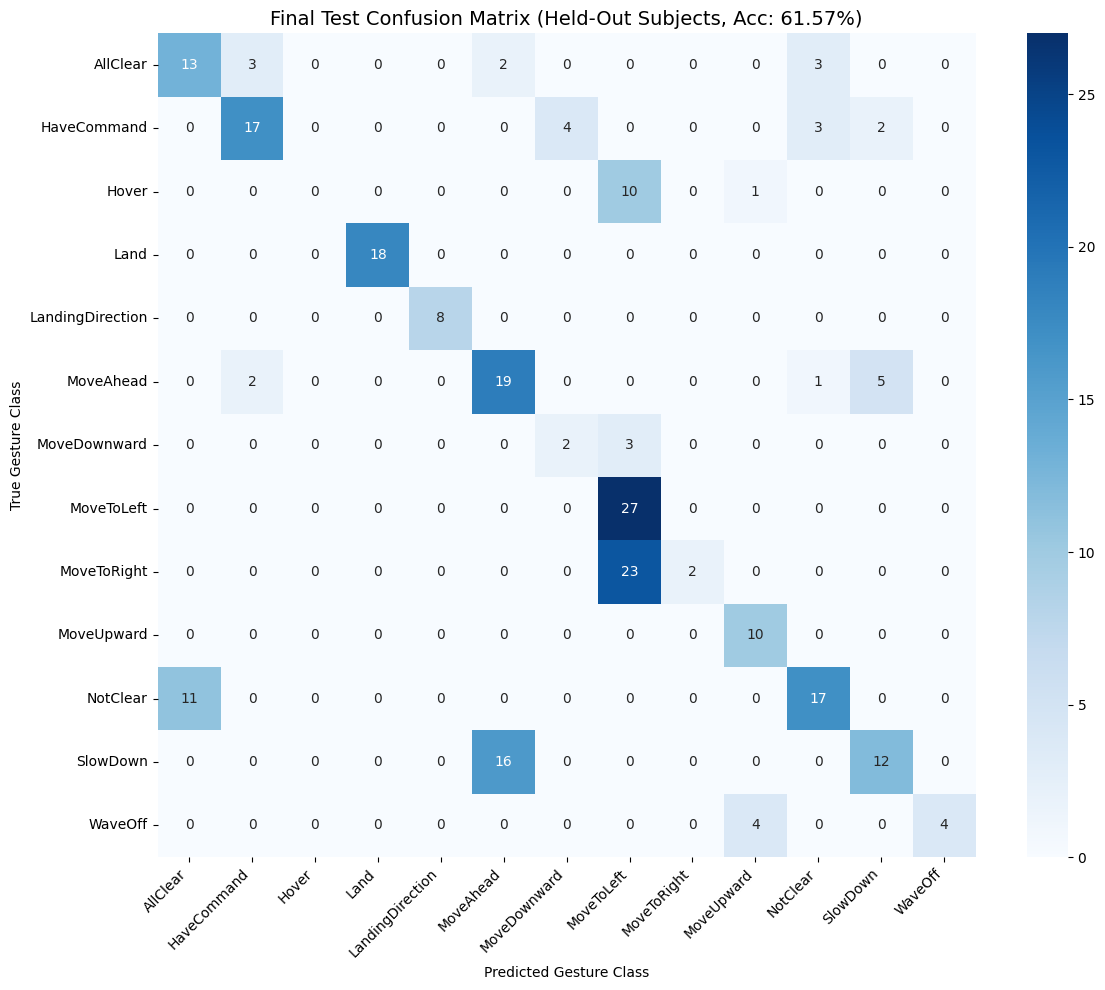

In [39]:
# Cell: FINAL TEST SET EVALUATION
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

final_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in final_test_loader:
        inputs = inputs.to(device)
        outputs = final_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"FINAL TEST ACCURACY (S13, S14, S15 -- never used for tuning): {test_acc:.2f}%\n")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_test_dataset.classes,
            yticklabels=final_test_dataset.classes)
plt.title(f'Final Test Confusion Matrix (Held-Out Subjects, Acc: {test_acc:.2f}%)', fontsize=14)
plt.ylabel('True Gesture Class')
plt.xlabel('Predicted Gesture Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
# Cell: Corrected Augmentation Pipeline (Final v2)
# Discovery Post-Mortem: RandomHorizontalFlip mirrors the image but does not update the
# label. For the mirror-symmetric pair MoveToLeft/MoveToRight, it silently mislabels 
# ~50% of training examples. We remove the horizontal flip; all other augmentation is kept.

train_transforms_v4 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

final_train_dataset_v2 = GestureDatasetBySubjects(root_data_path, TRAIN_SUBJECTS, transform=train_transforms_v4)
final_train_loader_v2 = DataLoader(final_train_dataset_v2, batch_size=16, shuffle=True, num_workers=2)

print(f"Final v2 Train instances: {len(final_train_dataset_v2)}")

Final v2 Train instances: 573


In [41]:
# Cell: Final Production Model v2 (Corrected Augmentation) - Training

final_model_v2 = Iteration5Model(dropout_rate=0.6).to(device)
final_optimizer_v2 = optim.Adam(final_model_v2.parameters(), lr=1e-4, weight_decay=5e-4)
final_criterion_v2 = nn.CrossEntropyLoss(label_smoothing=0.1)
final_scheduler_v2 = optim.lr_scheduler.ReduceLROnPlateau(final_optimizer_v2, mode='max', factor=0.5, patience=4)

print("Starting Final Production v2 Training (corrected augmentation)...")
final_history_v2 = train_model(
    final_model_v2, final_optimizer_v2, final_criterion_v2,
    final_train_loader_v2, final_val_loader,   
    num_epochs=25,
    label="Final v2",
    save_best_path="./best_final_production_model_v2.pt",
    scheduler=final_scheduler_v2
)
print("Training Complete!")

# Load the absolute best weights back into the model before final testing
final_model_v2.load_state_dict(torch.load("./best_final_production_model_v2.pt", map_location=device, weights_only=True))
final_model_v2.eval()
print(f"Loaded best Final v2 checkpoint (val acc {max(final_history_v2['val_acc']):.2f}%).")

Starting Final Production v2 Training (corrected augmentation)...
[Final v2] Epoch [1/25] Train Loss: 2.4859, Train Acc: 17.63% | Val Loss: 2.1867, Val Acc: 30.33%  <-- new best, checkpoint saved
[Final v2] Epoch [2/25] Train Loss: 1.8068, Train Acc: 45.20% | Val Loss: 1.6571, Val Acc: 43.44%  <-- new best, checkpoint saved
[Final v2] Epoch [3/25] Train Loss: 1.3527, Train Acc: 65.27% | Val Loss: 1.3091, Val Acc: 60.25%  <-- new best, checkpoint saved
[Final v2] Epoch [4/25] Train Loss: 1.0776, Train Acc: 79.76% | Val Loss: 1.3580, Val Acc: 57.38%
[Final v2] Epoch [5/25] Train Loss: 0.8795, Train Acc: 90.40% | Val Loss: 1.1608, Val Acc: 73.77%  <-- new best, checkpoint saved
[Final v2] Epoch [6/25] Train Loss: 0.7914, Train Acc: 94.42% | Val Loss: 1.1460, Val Acc: 76.64%  <-- new best, checkpoint saved
[Final v2] Epoch [7/25] Train Loss: 0.7504, Train Acc: 96.51% | Val Loss: 1.0708, Val Acc: 79.10%  <-- new best, checkpoint saved
[Final v2] Epoch [8/25] Train Loss: 0.7121, Train Acc: 9

FINAL v2 TEST ACCURACY: 67.36%

=== Per-Class Classification Report ===
                  precision    recall  f1-score   support

        AllClear      0.383     0.857     0.529        21
     HaveCommand      1.000     0.385     0.556        26
           Hover      0.000     0.000     0.000        11
            Land      1.000     0.889     0.941        18
LandingDirection      1.000     1.000     1.000         8
       MoveAhead      0.724     0.778     0.750        27
    MoveDownward      0.500     0.400     0.444         5
      MoveToLeft      0.730     1.000     0.844        27
     MoveToRight      1.000     0.720     0.837        25
      MoveUpward      0.556     1.000     0.714        10
        NotClear      1.000     0.214     0.353        28
        SlowDown      0.476     0.714     0.571        28
         WaveOff      1.000     0.875     0.933         8

        accuracy                          0.674       242
       macro avg      0.721     0.679     0.652       24

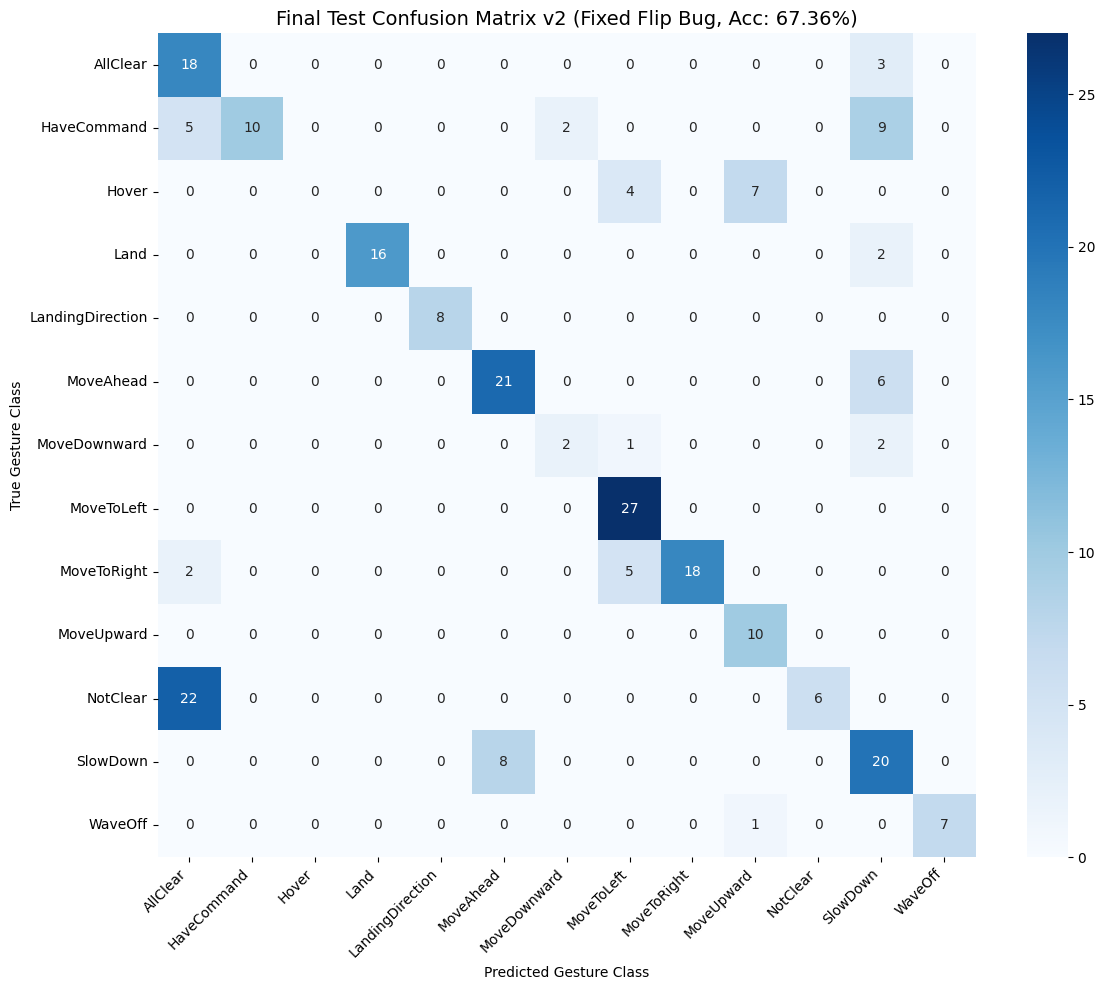

In [43]:
# Cell: FINAL TEST SET EVALUATION (v2) & Breakdown
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

final_model_v2.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in final_test_loader:
        inputs = inputs.to(device)
        outputs = final_model_v2(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"FINAL v2 TEST ACCURACY: {test_acc:.2f}%\n")

# 1. Per-Class Report
print("=== Per-Class Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=final_test_dataset.classes, digits=3, zero_division=0))

# 2. Per-Subject Breakdown
print("=== Per-Subject Test Accuracy ===")
for subject in TEST_SUBJECTS:
    subj_dataset = GestureDatasetBySubjects(root_data_path, [subject], transform=val_transforms_clean)
    subj_loader = DataLoader(subj_dataset, batch_size=16, shuffle=False, num_workers=2)
    subj_preds, subj_labels = [], []
    with torch.no_grad():
        for inputs, labels in subj_loader:
            inputs = inputs.to(device)
            outputs = final_model_v2(inputs)   
            _, preds = torch.max(outputs, 1)
            subj_preds.extend(preds.cpu().numpy())
            subj_labels.extend(labels.cpu().numpy())
    subj_acc = 100 * sum(p == l for p, l in zip(subj_preds, subj_labels)) / len(subj_labels)
    print(f"  {subject}: {subj_acc:.2f}% ({len(subj_labels)} instances)")

# 3. New Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_test_dataset.classes,
            yticklabels=final_test_dataset.classes)
plt.title(f'Final Test Confusion Matrix v2 (Fixed Flip Bug, Acc: {test_acc:.2f}%)', fontsize=14)
plt.ylabel('True Gesture Class')
plt.xlabel('Predicted Gesture Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()